In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import duckdb
import sys
sys.path.append('..')
from feature_engineering_utils import (
    create_all_features,
    create_basic_features,
    create_recency_features,
    create_advanced_features,
    get_all_feature_columns,
    select_features_by_correlation,
    create_bucketed_classes
)

## Define Target
We're predicting if a user will block someone in the second / third / fourth week of September 2024.

- Week 1 (features): Sept 1-7, 2024
- Week 2 (target): Sept 8-14, 2024
- Week 3 (target): Sept 15-21, 2024
- Week 4 (target): Sept 22-28, 2024

In [2]:
blocks_path = "../../data/ale_simplicistic_model/cleaned/blocks.parquet"
users_path = "../../data/ale_simplicistic_model/absolute/filtered/first_week_sept_blockers.parquet"

con = duckdb.connect()
con.execute("CREATE TABLE users_of_interest AS SELECT * FROM read_parquet(?)", [users_path])

query = """
WITH week2_blocks AS (
    SELECT 
        b.did_id,
        COUNT(*) as blocks_week2_initiated
    FROM read_parquet(?) b
    INNER JOIN users_of_interest uoi ON b.did_id = uoi.did_id
    WHERE b.created_date >= '2024-09-08' AND b.created_date < '2024-09-15'
    GROUP BY b.did_id
),
week3_blocks AS (
    SELECT 
        b.did_id,
        COUNT(*) as blocks_week3_initiated
    FROM read_parquet(?) b
    INNER JOIN users_of_interest uoi ON b.did_id = uoi.did_id
    WHERE b.created_date >= '2024-09-15' AND b.created_date < '2024-09-22'
    GROUP BY b.did_id
),
week4_blocks AS (
    SELECT 
        b.did_id,
        COUNT(*) as blocks_week4_initiated
    FROM read_parquet(?) b
    INNER JOIN users_of_interest uoi ON b.did_id = uoi.did_id
    WHERE b.created_date >= '2024-09-22' AND b.created_date < '2024-09-29'
    GROUP BY b.did_id
)
SELECT 
    uoi.did_id,
    COALESCE(wb2.blocks_week2_initiated, 0) as blocks_week2_initiated,
    COALESCE(wb3.blocks_week3_initiated, 0) as blocks_week3_initiated,
    COALESCE(wb4.blocks_week4_initiated, 0) as blocks_week4_initiated
FROM users_of_interest uoi
LEFT JOIN week2_blocks wb2 ON uoi.did_id = wb2.did_id
LEFT JOIN week3_blocks wb3 ON uoi.did_id = wb3.did_id
LEFT JOIN week4_blocks wb4 ON uoi.did_id = wb4.did_id
ORDER BY uoi.did_id
"""

target_table = con.execute(query, [blocks_path, blocks_path, blocks_path]).df()

print(f"Target variable created for {len(target_table)} users")
print(f"Users with blocks in week 2: {(target_table['blocks_week2_initiated'] > 0).sum()}")
print(f"Users with blocks in week 3: {(target_table['blocks_week3_initiated'] > 0).sum()}")
print(f"Users with blocks in week 4: {(target_table['blocks_week4_initiated'] > 0).sum()}")
print(f"\nTarget statistics:")
print(target_table[['blocks_week2_initiated', 'blocks_week3_initiated', 'blocks_week4_initiated']].describe())
print(f"\nSample of target table:")
print(target_table.head())

Target variable created for 100000 users
Users with blocks in week 2: 49183
Users with blocks in week 3: 42941
Users with blocks in week 4: 39785

Target statistics:
       blocks_week2_initiated  blocks_week3_initiated  blocks_week4_initiated
count           100000.000000            100000.00000           100000.000000
mean                 4.881430                 3.00079                3.094810
std                108.545163                43.68420               57.226947
min                  0.000000                 0.00000                0.000000
25%                  0.000000                 0.00000                0.000000
50%                  0.000000                 0.00000                0.000000
75%                  2.000000                 2.00000                2.000000
max              24343.000000              7955.00000            14963.000000

Sample of target table:
   did_id  blocks_week2_initiated  blocks_week3_initiated  \
0     148                       0             

## Bucketing Strategy
Convert integer count targets into three ordered activity classes:
- 0 blocks → class 0 (Inactive)
- 1–3 blocks → class 1 (Low activity)
- 4+ blocks → class 2 (High activity)

In [3]:
# Create binned classes for each week
target_table['blocks_week2_class'] = create_bucketed_classes(target_table['blocks_week2_initiated'])
target_table['blocks_week3_class'] = create_bucketed_classes(target_table['blocks_week3_initiated'])
target_table['blocks_week4_class'] = create_bucketed_classes(target_table['blocks_week4_initiated'])

print("Class distribution for Week 2:")
print(target_table['blocks_week2_class'].value_counts().sort_index())
print("\nClass distribution for Week 3:")
print(target_table['blocks_week3_class'].value_counts().sort_index())
print("\nClass distribution for Week 4:")
print(target_table['blocks_week4_class'].value_counts().sort_index())

Class distribution for Week 2:
blocks_week2_class
0    50817
1    29777
2    19406
Name: count, dtype: int64

Class distribution for Week 3:
blocks_week3_class
0    57059
1    27225
2    15716
Name: count, dtype: int64

Class distribution for Week 4:
blocks_week4_class
0    60215
1    24702
2    15083
Name: count, dtype: int64


✓ Image saved to: ../../data/ale_simplicistic_model/absolute/target_distribution.png


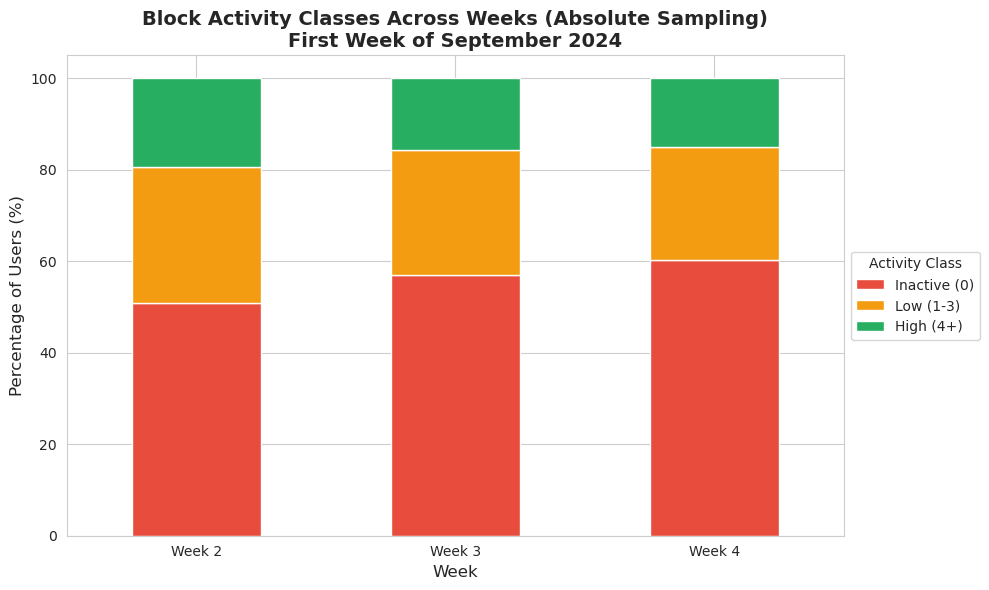


SUMMARY: Class Distribution Changes

Inactive (0):
  Week 2→3: 50,817 → 57,059 (+12.3%)
  Week 3→4: 57,059 → 60,215 (+5.5%)

Low (1-3):
  Week 2→3: 29,777 → 27,225 (-8.6%)
  Week 3→4: 27,225 → 24,702 (-9.3%)

High (4+):
  Week 2→3: 19,406 → 15,716 (-19.0%)
  Week 3→4: 15,716 → 15,083 (-4.0%)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Prepare data for visualization
class_names = ['Inactive (0)', 'Low (1-3)', 'High (4+)']
weeks = ['Week 2', 'Week 3', 'Week 4']

# Count distribution for each week
week2_counts = target_table['blocks_week2_class'].value_counts().sort_index()
week3_counts = target_table['blocks_week3_class'].value_counts().sort_index()
week4_counts = target_table['blocks_week4_class'].value_counts().sort_index()

# Create DataFrame for plotting
plot_data = pd.DataFrame({
    'Week 2': week2_counts.values,
    'Week 3': week3_counts.values,
    'Week 4': week4_counts.values
}, index=class_names)

# Percentage stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct = plot_data.div(plot_data.sum(axis=0), axis=1) * 100
plot_data_pct.T.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#f39c12', '#27ae60'])
ax.set_title('Block Activity Classes Across Weeks (Absolute Sampling)\nFirst Week of September 2024', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Percentage of Users (%)', fontsize=12)
ax.legend(title='Activity Class', loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

# Save high-quality image
output_path = '../../data/ale_simplicistic_model/absolute/target_distribution.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Image saved to: {output_path}")

plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Class Distribution Changes")
print("="*60)
for cls_idx, cls_name in enumerate(class_names):
    w2 = plot_data.loc[cls_name, 'Week 2']
    w3 = plot_data.loc[cls_name, 'Week 3']
    w4 = plot_data.loc[cls_name, 'Week 4']
    change_2_3 = ((w3 - w2) / w2 * 100) if w2 > 0 else float('inf')
    change_3_4 = ((w4 - w3) / w3 * 100) if w3 > 0 else float('inf')
    print(f"\n{cls_name}:")
    print(f"  Week 2→3: {w2:,} → {w3:,} ({change_2_3:+.1f}%)")
    print(f"  Week 3→4: {w3:,} → {w4:,} ({change_3_4:+.1f}%)")

# Feature Engineering

In [5]:
# Load user activity data
user_path = "../../data/ale_simplicistic_model/absolute/processed/user_activity.parquet"
user_df = pd.read_parquet(user_path)
print('Loaded user activity rows:', len(user_df))

# Merge with target to align users
df = user_df.merge(target_table[['did_id']], on='did_id', how='inner')

print(f"\nDataset: {len(df)} users")
print(f"Columns: {list(user_df.columns)}")

Loaded user activity rows: 100000

Dataset: 100000 users
Columns: ['did_id', 'posts_vec', 'blocks_actor_vec', 'blocks_subject_vec', 'follows_actor_vec', 'follows_subject_vec', 'likes_actor_vec', 'likes_subject_vec']


In [2]:
# Create all features using utility functions
print("Creating features...")
df = create_basic_features(df)
df = create_recency_features(df)
df = create_advanced_features(df)

print(f"✓ Features created")
print(f"\nNew columns added: {len(get_all_feature_columns())} features")
print(f"Total columns: {len(df.columns)}")

Creating features...


NameError: name 'df' is not defined

# Feature Selection

In [7]:
# Get all feature columns
all_feature_columns = get_all_feature_columns()

# Prepare data for feature selection
features_with_id = df[['did_id'] + all_feature_columns].fillna(0)
X_temp = features_with_id.merge(target_table, on='did_id', how='inner')

# Extract targets
y_count = X_temp['blocks_week2_initiated']
y_class = X_temp['blocks_week2_class']

# Select features based on correlation with class target
X_temp_features = X_temp[all_feature_columns]
CORRELATION_THRESHOLD = 0.05

feature_columns, corr_with_class = select_features_by_correlation(
    X_temp_features, 
    y_class, 
    threshold=CORRELATION_THRESHOLD,
    verbose=True
)

FEATURE SELECTION: Correlation-based filtering

Correlation threshold: 0.05
Original features: 30
Strong features (≥ 0.05): 20
Removed features: 10

✓ Selected features:
  - blocks_initiated_active_days: 0.4094
  - blocks_initiated_last_day: 0.2778
  - blocks_ratio_initiated_received: 0.1561
  - likes_received_active_days: 0.1526
  - likes_made_active_days: 0.1423
  - last_active_overall: 0.1354
  - likes_made_total: 0.1347
  - blocks_received_active_days: 0.1210
  - likes_made_last_day: 0.1129
  - blocks_initiated_total: 0.0992
  - posts_avg: 0.0940
  - posts_total: 0.0940
  - blocks_net_balance: 0.0791
  - blocks_initiated_per_active_day: 0.0789
  - posts_active_days: 0.0747
  - follows_made_last_day: 0.0695
  - follows_made_active_days: 0.0588
  - likes_made_first_day: 0.0578
  - blocks_to_posts_ratio: 0.0541
  - posts_last_active_day: 0.0534

Removed weak features:
  - posts_day0: 0.0465
  - blocks_received_total: 0.0188
  - follows_made_total: 0.0117
  - follows_received_total: 0.

In [8]:
# Create final feature matrix with selected features
features_with_id_final = df[['did_id'] + feature_columns].fillna(0)
X_final = features_with_id_final.merge(target_table, on='did_id', how='inner')

# Extract final targets
y_count_final = X_final['blocks_week2_initiated']
y_class_final = X_final['blocks_week2_class']

# Keep only feature columns
X_final_features = X_final[feature_columns]

print(f"\n✓ Final feature matrix:")
print(f"  Feature shape: {X_final_features.shape}")
print(f"  Target shape: {y_class_final.shape}")
print(f"  Class distribution: {y_class_final.value_counts().sort_index().to_dict()}")


✓ Final feature matrix:
  Feature shape: (100000, 20)
  Target shape: (100000,)
  Class distribution: {0: 50817, 1: 29777, 2: 19406}


In [9]:
# Compare correlations: raw count vs bucketed class
print("\n" + "="*80)
print("CORRELATION ANALYSIS: Raw Count vs Bucketed Class")
print("="*80)

corr_count = X_final_features.corrwith(y_count_final).sort_values(ascending=False)
corr_class = X_final_features.corrwith(y_class_final).sort_values(ascending=False)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'corr_with_count': corr_count,
    'corr_with_class': corr_class,
    'diff': (corr_class - corr_count).abs()
}).sort_values('corr_with_class', ascending=False)

print("\nTop 15 features by correlation with BUCKETED CLASS:")
print(comparison.head(15).to_string())

print("\n\nBottom 10 features:")
print(comparison.tail(10).to_string())


CORRELATION ANALYSIS: Raw Count vs Bucketed Class

Top 15 features by correlation with BUCKETED CLASS:
                                 corr_with_count  corr_with_class      diff
blocks_initiated_active_days            0.069441         0.409426  0.339985
blocks_initiated_last_day               0.034421         0.277790  0.243369
blocks_ratio_initiated_received         0.117909         0.156118  0.038208
likes_received_active_days              0.012803         0.152644  0.139841
likes_made_active_days                  0.008763         0.142295  0.133532
last_active_overall                     0.009176         0.135407  0.126232
likes_made_total                        0.012473         0.134671  0.122198
blocks_received_active_days             0.050021         0.120997  0.070976
likes_made_last_day                     0.005169         0.112905  0.107736
blocks_initiated_total                  0.447086         0.099163  0.347923
posts_avg                               0.008166         0.0

✓ Correlation plot saved to: ../../data/ale_simplicistic_model/absolute/feature_correlations.png


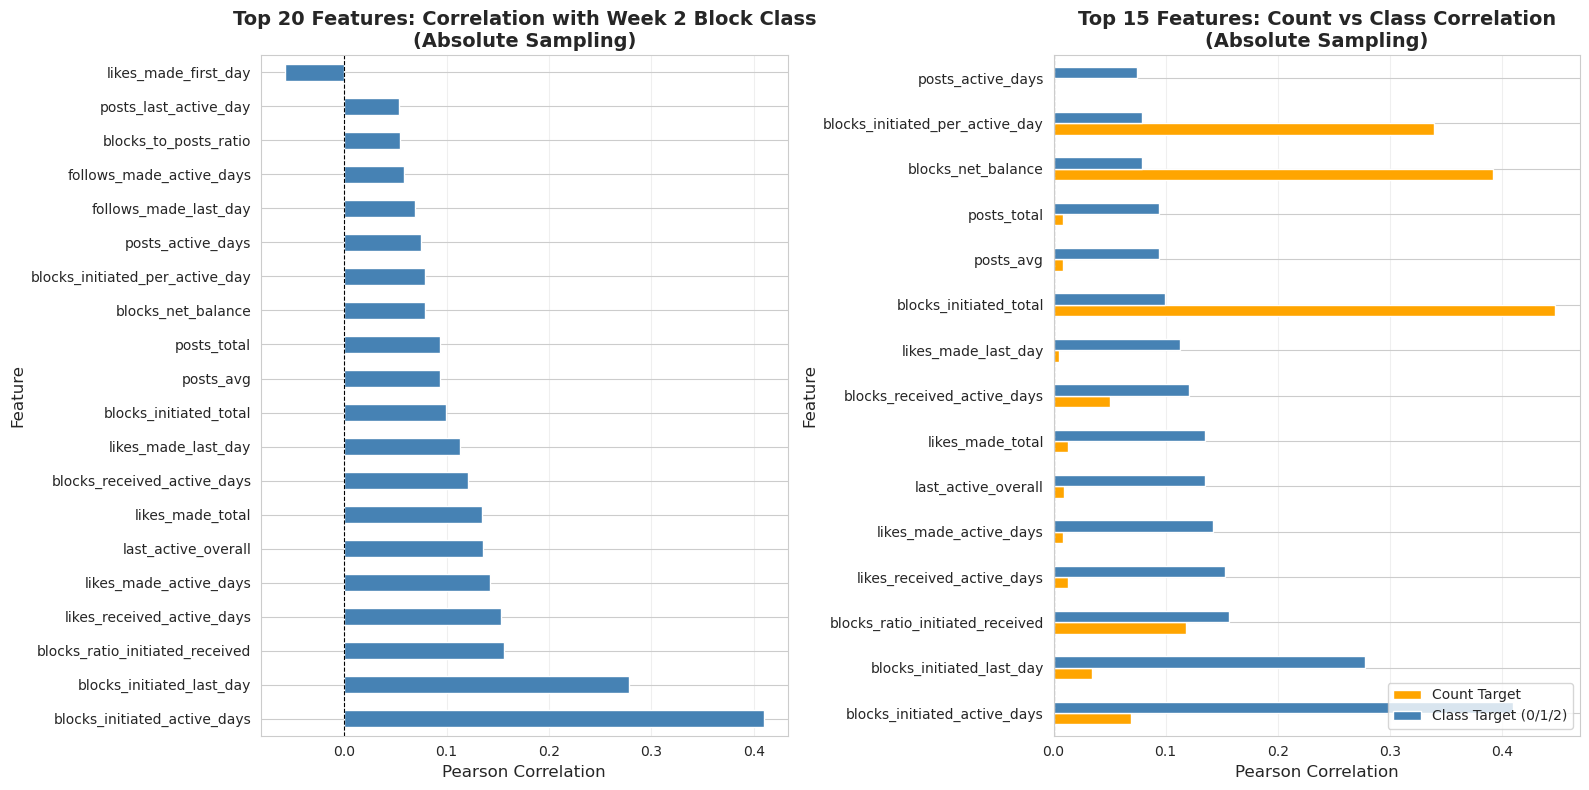

In [10]:
# Visualize feature correlations
import matplotlib.pyplot as plt
import seaborn as sns

# Top features
top_n = 20
top_features = comparison.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Bar plot: correlation with class
top_features['corr_with_class'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Top {top_n} Features: Correlation with Week 2 Block Class\n(Absolute Sampling)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(axis='x', alpha=0.3)

# 2. Comparison: count vs class correlation
top_features_plot = top_features.head(15)[['corr_with_count', 'corr_with_class']]
top_features_plot.plot(kind='barh', ax=axes[1], color=['orange', 'steelblue'])
axes[1].set_title('Top 15 Features: Count vs Class Correlation\n(Absolute Sampling)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].legend(['Count Target', 'Class Target (0/1/2)'], loc='lower right')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save visualization
output_path = '../../data/ale_simplicistic_model/absolute/feature_correlations.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Correlation plot saved to: {output_path}")

plt.show()

# Save Features and Targets

In [11]:
# Save features and targets
features_output_path = "../../data/ale_simplicistic_model/absolute/featured/features.parquet"
target_output_path = "../../data/ale_simplicistic_model/absolute/featured/target.parquet"

# Save features WITH did_id for proper alignment with targets
features_final = df[['did_id'] + feature_columns].fillna(0)
features_final = features_final.merge(target_table[['did_id']], on='did_id', how='inner')

print("="*80)
print("SAVING ABSOLUTE SAMPLING DATASET")
print("="*80)
print(f"✓ Features include did_id for proper alignment: {list(features_final.columns)[:5]}...")
features_final.to_parquet(features_output_path, index=False)
print(f"✓ Features saved to: {features_output_path}")
print(f"  Shape: {features_final.shape}")
print(f"  Columns: {len(features_final.columns)}")

# Save target table with both count and class for all weeks
target_save = target_table[[
    'did_id',
    'blocks_week2_initiated', 'blocks_week2_class',
    'blocks_week3_initiated', 'blocks_week3_class',
    'blocks_week4_initiated', 'blocks_week4_class'
]]
target_save.to_parquet(target_output_path, index=False)
print(f"\n✓ Targets saved to: {target_output_path}")
print(f"  Shape: {target_save.shape}")
print(f"  Week 2 class distribution: {target_save['blocks_week2_class'].value_counts().sort_index().to_dict()}")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Dataset: {len(features_final)} users")
print(f"Features: {len(feature_columns)} selected features")
print(f"Time period: First week of September 2024 (Sept 1-7)")
print(f"Target weeks: Week 2 (Sept 8-14), Week 3 (Sept 15-21), Week 4 (Sept 22-28)")

# Close DuckDB connection
con.close()

SAVING ABSOLUTE SAMPLING DATASET
✓ Features include did_id for proper alignment: ['did_id', 'posts_total', 'posts_avg', 'posts_active_days', 'blocks_initiated_total']...
✓ Features saved to: ../../data/ale_simplicistic_model/absolute/featured/features.parquet
  Shape: (100000, 21)
  Columns: 21

✓ Targets saved to: ../../data/ale_simplicistic_model/absolute/featured/target.parquet
  Shape: (100000, 7)
  Week 2 class distribution: {0: 50817, 1: 29777, 2: 19406}

SUMMARY
Dataset: 100000 users
Features: 20 selected features
Time period: First week of September 2024 (Sept 1-7)
Target weeks: Week 2 (Sept 8-14), Week 3 (Sept 15-21), Week 4 (Sept 22-28)
